# Análisis de resultados — Pozo de Potencial Infinito

Este notebook analiza los resultados del estudio de sensibilidad sobre la PINN
aplicada al pozo de potencial infinito. Se estudian los siguientes ejes:

1. **Puntos de colocación**: 50, 100, 250, 500 (base), 1000
2. **Sampler**: LHS (base) vs. grid
3. **Optimizador**: Adam (base) vs. Adam+L-BFGS
4. **Arquitectura**: [32,32,32] (base) vs. [64,64,64]
5. **Pesos dinámicos**: desactivados (base) vs. activados
6. **Learning rate**: 0.001 (base) vs. 0.01
7. **Puntos de entrenamiento**: 3, 5, 10, 15 (base), 30
8. **Región de entrenamiento**: 20% (base) vs. 50%
9. **Cruce puntos × región**: combinaciones con región 50%
10. **Estado cuántico**: n = 1, 2 (base), 3, 4
11. **Sin datos supervisados**: solo física (use_data = False)

Cada configuración se ejecuta con 10 seeds distintas.
La referencia numérica es FDM (Diferencias Finitas).
La PINN aprende el autovalor $\varepsilon$ como parámetro adicional,
lo que permite comparar su precisión frente al valor exacto y al FDM.

In [3]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    "font.family":         "serif",
    "font.size":           12,
    "axes.linewidth":      1.2,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi":          150,
})

RESULTS_DIR = Path("results")
FIGS_DIR    = Path("figures_analysis_pozo")
FIGS_DIR.mkdir(exist_ok=True)

C_PINN = "#1f4e96"
C_NN   = "#e07b39"
C_FDM  = "#888888"

In [4]:
records_pozo = []

for fpath in sorted(RESULTS_DIR.glob("pozo_infinito/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)

    cfg = d["config"]
    res = d["resultados_finales"]

    records_pozo.append({
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "estado_n":            cfg["estado_n"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_domain_points":   cfg["num_domain_points"],
        "num_train_points":    cfg["num_train_points"],
        "train_region":        cfg["train_region"],
        "sampler":             cfg["sampler"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "use_orthogonality":   cfg["use_orthogonality"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        "use_data":            cfg["use_data"],
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2"],
        "time_pinn":           res["pinn"]["time_s"],
        "epsilon_exacto":      res["pinn"]["epsilon_exacto"],
        "epsilon_learned":     res["pinn"]["epsilon_learned"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2"],
        "time_nn":             res["nn"]["time_s"],
        # ── Resultados FDM ─────────────────────────────────────────
        "error_l2_fdm":        res["fdm"]["error_L2"],
        "time_fdm":            res["fdm"]["time_s"],
        "epsilon_fdm":         res["fdm"]["epsilon_fdm"],
    })

df_pozo = pd.DataFrame(records_pozo)
print(f"Total experimentos cargados: {len(df_pozo)}")
print(f"Estados cuánticos presentes: {sorted(df_pozo['estado_n'].unique())}")
df_pozo.head()

Total experimentos cargados: 230
Estados cuánticos presentes: [1, 2, 3, 4]


,seed,estado_n,epochs,lr,num_domain_points,num_train_points,train_region,sampler,use_dynamic_weights,use_orthogonality,...,use_data,error_l2_pinn,time_pinn,epsilon_exacto,epsilon_learned,error_l2_nn,time_nn,error_l2_fdm,time_fdm,epsilon_fdm
0,42,1,10000,0.001,500,15,0.2,lhs,False,False,...,True,0.000201,36.640467,4.934802,4.934831,0.793272,7.572976,0.002076,0.205011,4.915098
1,123,1,10000,0.001,500,15,0.2,lhs,False,False,...,True,0.000123,36.517163,4.934802,4.934970,0.786515,7.659991,0.002076,0.211010,4.915098
2,7,1,10000,0.001,500,15,0.2,lhs,False,False,...,True,0.000053,36.748954,4.934802,4.934816,0.809370,7.635984,0.002076,0.207006,4.915098
3,99,1,10000,0.001,500,15,0.2,lhs,False,False,...,True,0.000024,36.714868,4.934802,4.934850,0.741788,7.585913,0.002076,0.210006,4.915098
4,2024,1,10000,0.001,500,15,0.2,lhs,False,False,...,True,0.000040,36.735509,4.934802,4.934808,0.764798,7.611986,0.002076,0.212010,4.915098


In [5]:
BASE_POZO = {
    "estado_n":            2,
    "num_domain_points":   500,
    "num_train_points":    15,
    "train_region":        0.2,
    "sampler":             "lhs",
    "use_dynamic_weights": False,
    "use_orthogonality":   False,
    "optimizer":           "adam",
    "hidden_layers":       "[32, 32, 32]",
    "lr":                  0.001,
    "use_data":            True,
}

def is_base_pozo(row):
    return all(row[k] == v for k, v in BASE_POZO.items())

df_pozo["is_base"] = df_pozo.apply(is_base_pozo, axis=1)
df_base_pozo = df_pozo[df_pozo["is_base"]]

print(f"Experimentos BASE: {len(df_base_pozo)} (esperados: 10)")
print(f"\nError L2 PINN — media: {df_base_pozo['error_l2_pinn'].mean():.4e} "
      f"± {df_base_pozo['error_l2_pinn'].std():.4e}")
print(f"Error L2 NN   — media: {df_base_pozo['error_l2_nn'].mean():.4e} "
      f"± {df_base_pozo['error_l2_nn'].std():.4e}")
print(f"Error L2 FDM  — media: {df_base_pozo['error_l2_fdm'].mean():.4e} "
      f"± {df_base_pozo['error_l2_fdm'].std():.4e}")
print(f"\nAutovalor exacto (n=2):  {df_base_pozo['epsilon_exacto'].iloc[0]:.6f}")
print(f"Autovalor PINN  — media: {df_base_pozo['epsilon_learned'].mean():.6f} "
      f"± {df_base_pozo['epsilon_learned'].std():.6f}")
print(f"Autovalor FDM   — media: {df_base_pozo['epsilon_fdm'].mean():.6f} "
      f"± {df_base_pozo['epsilon_fdm'].std():.6f}")
print(f"\nTiempo PINN — media: {df_base_pozo['time_pinn'].mean():.2f}s "
      f"± {df_base_pozo['time_pinn'].std():.2f}s")
print(f"Tiempo NN   — media: {df_base_pozo['time_nn'].mean():.2f}s "
      f"± {df_base_pozo['time_nn'].std():.2f}s")
print(f"Tiempo FDM  — media: {df_base_pozo['time_fdm'].mean():.4f}s")

Experimentos BASE: 10 (esperados: 10)

Error L2 PINN — media: 3.9263e-03 ± 5.0726e-03
Error L2 NN   — media: 1.9231e+00 ± 4.8972e-02
Error L2 FDM  — media: 3.7735e-03 ± 0.0000e+00

Autovalor exacto (n=2):  19.739209
Autovalor PINN  — media: 19.739185 ± 0.000125
Autovalor FDM   — media: 19.660345 ± 0.000000

Tiempo PINN — media: 37.17s ± 0.43s
Tiempo NN   — media: 7.67s ± 0.07s
Tiempo FDM  — media: 0.2116s


## Eje 1 — Puntos de colocación

Se varía el número de puntos de colocación entre 50 y 1000, manteniendo el resto
de hiperparámetros en su configuración BASE. La NN pura no depende de este parámetro
(sus puntos de entrenamiento son fijos), por lo que se representa como referencia
horizontal.

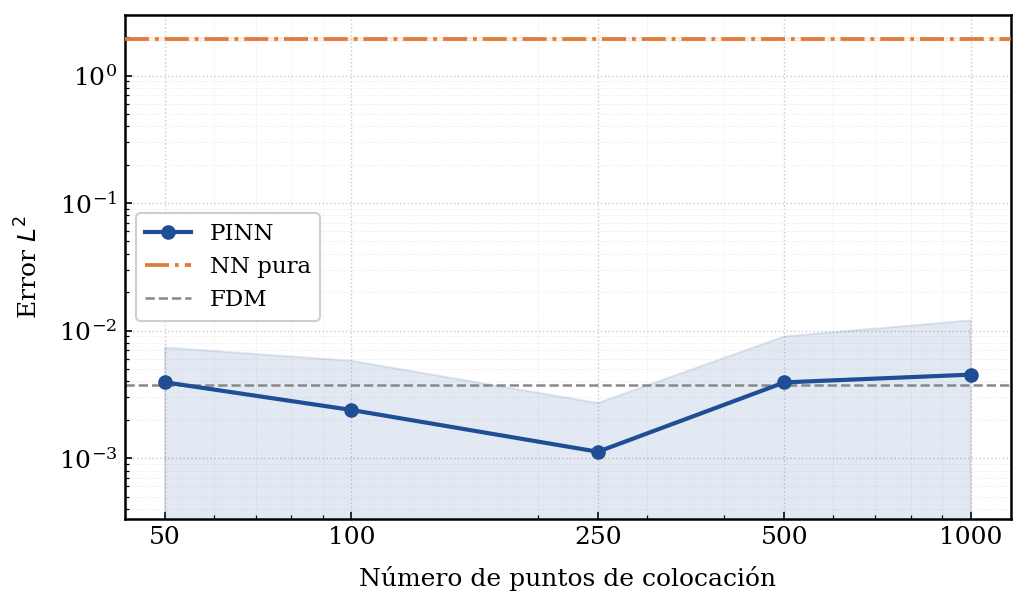

NN pura: 1.9231e+00 ± 4.8972e-02
FDM:     3.7735e-03

PINN por puntos de colocación:
num_domain_points error_l2_pinn          error_l2_nn         
                           mean      std        mean      std
               50      0.003934 0.003430    1.923093 0.048972
              100      0.002386 0.003411    1.923093 0.048972
              250      0.001122 0.001582    1.923093 0.048972
              500      0.003926 0.005073    1.923093 0.048972
             1000      0.004517 0.007513    1.923093 0.048972


In [6]:
configs_eje1 = [50, 100, 250, 500, 1000]

mask_eje1_pozo = (
    df_pozo["estado_n"].isin([2]) &
    df_pozo["num_domain_points"].isin(configs_eje1) &
    (df_pozo["num_train_points"]    == BASE_POZO["num_train_points"]) &
    (df_pozo["train_region"]        == BASE_POZO["train_region"]) &
    (df_pozo["sampler"]             == BASE_POZO["sampler"]) &
    (df_pozo["use_dynamic_weights"] == BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]   == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]           == BASE_POZO["optimizer"]) &
    (df_pozo["hidden_layers"]       == BASE_POZO["hidden_layers"]) &
    (df_pozo["lr"]                  == BASE_POZO["lr"]) &
    (df_pozo["use_data"]            == BASE_POZO["use_data"])
)

df_eje1_pozo = df_pozo[mask_eje1_pozo].groupby("num_domain_points")[
    ["error_l2_pinn", "error_l2_nn"]
].agg(["mean", "std"]).reset_index()

x   = df_eje1_pozo["num_domain_points"].values
y_p = df_eje1_pozo["error_l2_pinn"]["mean"].values
s_p = df_eje1_pozo["error_l2_pinn"]["std"].values
y_nn  = df_base_pozo["error_l2_nn"].mean()
s_nn  = df_base_pozo["error_l2_nn"].std()
y_fdm = df_base_pozo["error_l2_fdm"].mean()

fig, ax = plt.subplots(figsize=(7, 4.2))

ax.plot(x, y_p, "o-", color=C_PINN, linewidth=2, markersize=6,
        zorder=3, label="PINN")
ax.fill_between(x, y_p - s_p, y_p + s_p,
                color=C_PINN, alpha=0.12, zorder=2)
ax.axhline(y_nn, color=C_NN, linewidth=1.8, linestyle="-.",
           zorder=3, label="NN pura")
ax.axhspan(y_nn - s_nn, y_nn + s_nn,
           color=C_NN, alpha=0.08, zorder=1)
ax.axhline(y_fdm, color=C_FDM, linewidth=1.2, linestyle="--",
           zorder=2, label="FDM")

ax.set_xlabel("Número de puntos de colocación", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(configs_eje1)
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=11)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje1_colocation_points.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"NN pura: {y_nn:.4e} ± {s_nn:.4e}")
print(f"FDM:     {y_fdm:.4e}")
print("\nPINN por puntos de colocación:")
print(df_eje1_pozo.to_string(index=False))

## Eje 2 — Sampler

Se compara el muestreo Latin Hypercube (LHS) frente a malla uniforme (grid) para
los puntos de colocación. Al igual que en el oscilador clásico, el sampler no
afecta a la NN pura, por lo que esta se representa como referencia horizontal.

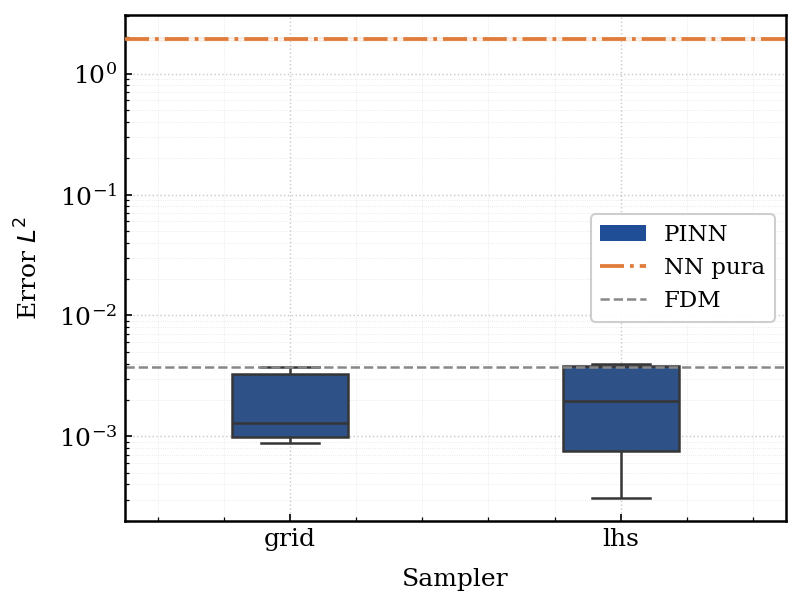

grid: PINN=3.7348e-03 ± 4.9032e-03
lhs: PINN=3.9263e-03 ± 5.0726e-03
NN pura: 1.9231e+00 ± 4.8972e-02
FDM:     3.7735e-03


In [7]:
mask_eje2_pozo = (
    df_pozo["sampler"].isin(["lhs", "grid"]) &
    (df_pozo["estado_n"]           == BASE_POZO["estado_n"]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["num_train_points"]   == BASE_POZO["num_train_points"]) &
    (df_pozo["train_region"]       == BASE_POZO["train_region"]) &
    (df_pozo["use_dynamic_weights"]== BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]          == BASE_POZO["optimizer"]) &
    (df_pozo["hidden_layers"]      == BASE_POZO["hidden_layers"]) &
    (df_pozo["lr"]                 == BASE_POZO["lr"]) &
    (df_pozo["use_data"]           == BASE_POZO["use_data"])
)

df_eje2_pozo = df_pozo[mask_eje2_pozo][["sampler", "error_l2_pinn"]].copy()

fig, ax = plt.subplots(figsize=(5.5, 4.2))

sns.boxplot(
    data=df_eje2_pozo, x="sampler", y="error_l2_pinn",
    color=C_PINN, width=0.35, linewidth=1.2,
    showfliers=False, ax=ax
)
ax.axhline(df_base_pozo["error_l2_nn"].mean(), color=C_NN, linewidth=1.8,
           linestyle="-.", zorder=3, label="NN pura")
ax.axhspan(
    df_base_pozo["error_l2_nn"].mean() - df_base_pozo["error_l2_nn"].std(),
    df_base_pozo["error_l2_nn"].mean() + df_base_pozo["error_l2_nn"].std(),
    color=C_NN, alpha=0.08, zorder=1
)
ax.axhline(df_base_pozo["error_l2_fdm"].mean(), color=C_FDM, linewidth=1.2,
           linestyle="--", zorder=2, label="FDM")

from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=11)

ax.set_xlabel("Sampler", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje2_sampler.png", dpi=300, bbox_inches="tight")
plt.show()

for sampler, grp in df_pozo[mask_eje2_pozo].groupby("sampler"):
    print(f"{sampler}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e}")
print(f"NN pura: {df_base_pozo['error_l2_nn'].mean():.4e} ± {df_base_pozo['error_l2_nn'].std():.4e}")
print(f"FDM:     {df_base_pozo['error_l2_fdm'].mean():.4e}")

## Eje 3 — Optimizador

Se compara Adam puro frente a la estrategia Adam+L-BFGS (cambio de fase en la
mitad del entrenamiento). El optimizador afecta tanto a la PINN como a la NN,
por lo que la comparación tripartita es completa.

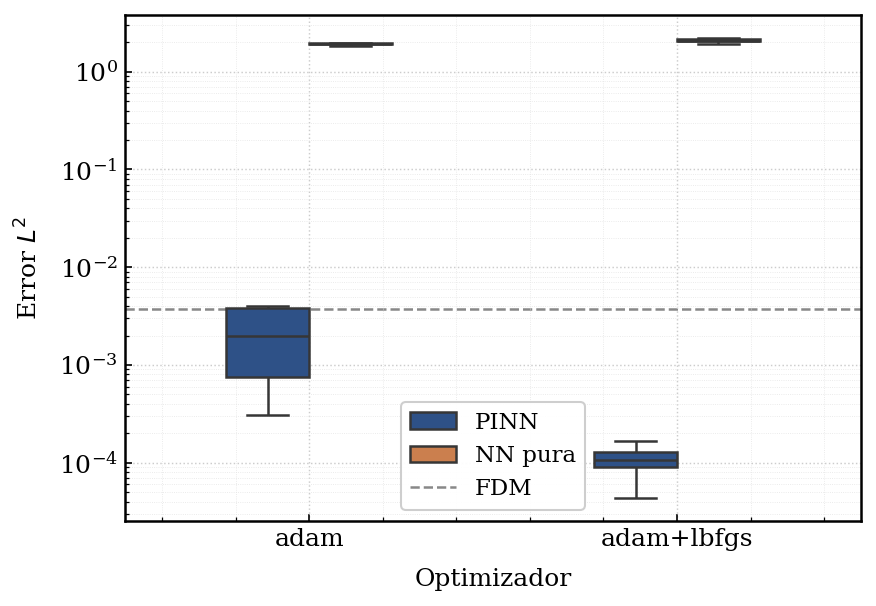

adam: PINN=3.9263e-03 ± 5.0726e-03 | NN=1.9231e+00 ± 4.8972e-02
adam+lbfgs: PINN=1.0304e-04 ± 4.1793e-05 | NN=2.0811e+00 ± 9.1587e-02
FDM: 3.7735e-03


In [8]:
mask_eje3_pozo = (
    df_pozo["optimizer"].isin(["adam", "adam+lbfgs"]) &
    (df_pozo["estado_n"]           == BASE_POZO["estado_n"]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["num_train_points"]   == BASE_POZO["num_train_points"]) &
    (df_pozo["train_region"]       == BASE_POZO["train_region"]) &
    (df_pozo["sampler"]            == BASE_POZO["sampler"]) &
    (df_pozo["use_dynamic_weights"]== BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["hidden_layers"]      == BASE_POZO["hidden_layers"]) &
    (df_pozo["lr"]                 == BASE_POZO["lr"]) &
    (df_pozo["use_data"]           == BASE_POZO["use_data"])
)

df_eje3_pozo_long = df_pozo[mask_eje3_pozo].melt(
    id_vars=["optimizer"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.boxplot(
    data=df_eje3_pozo_long, x="optimizer", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(
    df_base_pozo["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", zorder=0, label="FDM"
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Optimizador", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje3_optimizer.png", dpi=300, bbox_inches="tight")
plt.show()

for opt, grp in df_pozo[mask_eje3_pozo].groupby("optimizer"):
    print(f"{opt}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"FDM: {df_base_pozo['error_l2_fdm'].mean():.4e}")

## Eje 4 — Arquitectura

Se compara la arquitectura base [32, 32, 32] frente a [64, 64, 64]. Al doblar
la capacidad de la red, tanto la PINN como la NN disponen de más parámetros,
por lo que la comparación tripartita es directa.

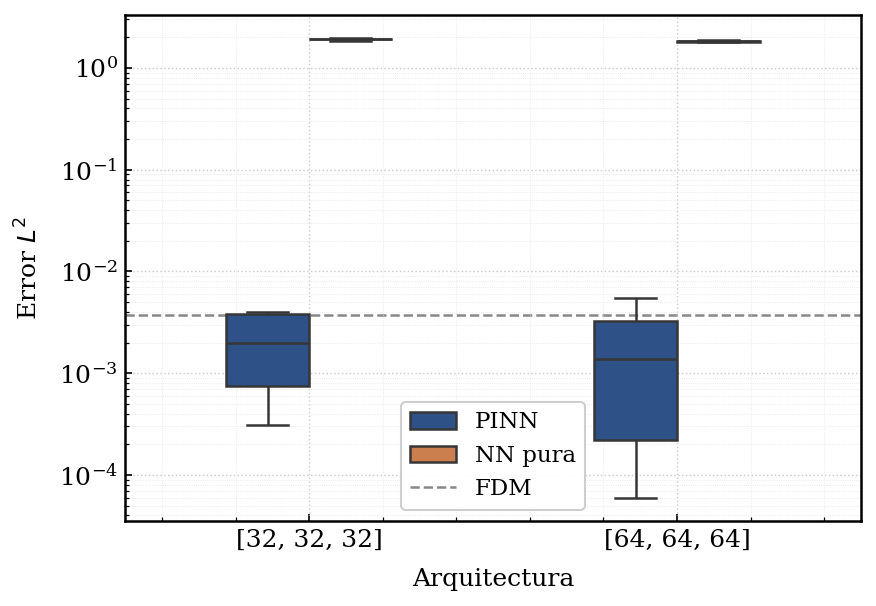

[32, 32, 32]: PINN=3.9263e-03 ± 5.0726e-03 | NN=1.9231e+00 ± 4.8972e-02
[64, 64, 64]: PINN=1.8952e-03 ± 1.9391e-03 | NN=1.8351e+00 ± 3.3794e-02
FDM: 3.7735e-03


In [9]:
mask_eje4_pozo = (
    df_pozo["hidden_layers"].isin(["[32, 32, 32]", "[64, 64, 64]"]) &
    (df_pozo["estado_n"]           == BASE_POZO["estado_n"]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["num_train_points"]   == BASE_POZO["num_train_points"]) &
    (df_pozo["train_region"]       == BASE_POZO["train_region"]) &
    (df_pozo["sampler"]            == BASE_POZO["sampler"]) &
    (df_pozo["use_dynamic_weights"]== BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]          == BASE_POZO["optimizer"]) &
    (df_pozo["lr"]                 == BASE_POZO["lr"]) &
    (df_pozo["use_data"]           == BASE_POZO["use_data"])
)

df_eje4_pozo_long = df_pozo[mask_eje4_pozo].melt(
    id_vars=["hidden_layers"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.boxplot(
    data=df_eje4_pozo_long, x="hidden_layers", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    width=0.45, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(
    df_base_pozo["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", zorder=0, label="FDM"
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Arquitectura", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje4_architecture.png", dpi=300, bbox_inches="tight")
plt.show()

for arch, grp in df_pozo[mask_eje4_pozo].groupby("hidden_layers"):
    print(f"{arch}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"FDM: {df_base_pozo['error_l2_fdm'].mean():.4e}")

## Eje 5 — Pesos dinámicos

Se compara el entrenamiento con pesos fijos (λ = 1 para todos los términos)
frente a pesos dinámicos adaptativos. Los pesos dinámicos solo afectan a la
PINN; la NN pura es insensible a este parámetro y se omite de la visualización.

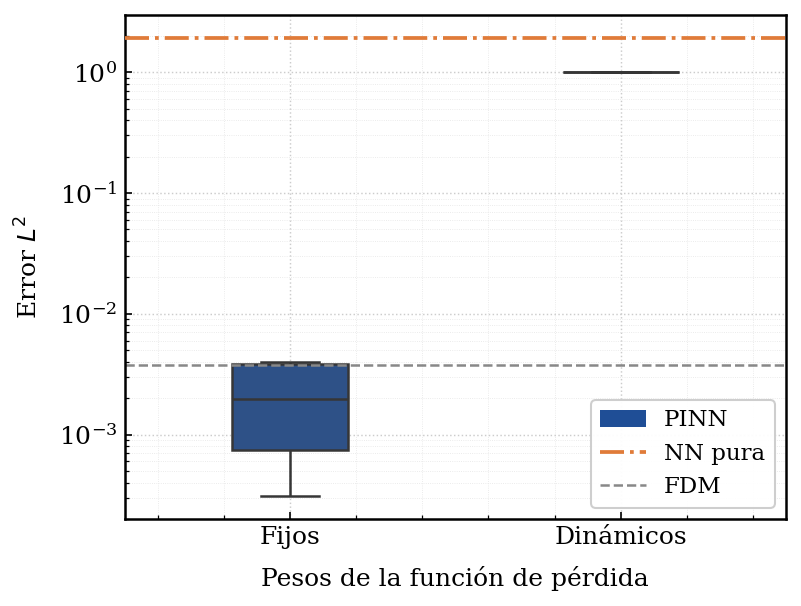

Fijos: PINN=3.9263e-03 ± 5.0726e-03
Dinámicos: PINN=9.9988e-01 ± 2.0442e-04
NN pura: 1.9231e+00 ± 4.8972e-02
FDM:     3.7735e-03


In [10]:
mask_eje5_pozo = (
    (df_pozo["estado_n"]           == BASE_POZO["estado_n"]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["num_train_points"]   == BASE_POZO["num_train_points"]) &
    (df_pozo["train_region"]       == BASE_POZO["train_region"]) &
    (df_pozo["sampler"]            == BASE_POZO["sampler"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]          == BASE_POZO["optimizer"]) &
    (df_pozo["hidden_layers"]      == BASE_POZO["hidden_layers"]) &
    (df_pozo["lr"]                 == BASE_POZO["lr"]) &
    (df_pozo["use_data"]           == BASE_POZO["use_data"])
)

df_eje5_pozo = df_pozo[mask_eje5_pozo].copy()
df_eje5_pozo["use_dynamic_weights"] = df_eje5_pozo["use_dynamic_weights"].astype(str).map(
    {"False": "Fijos", "True": "Dinámicos"}
)

fig, ax = plt.subplots(figsize=(5.5, 4.2))

sns.boxplot(
    data=df_eje5_pozo, x="use_dynamic_weights", y="error_l2_pinn",
    color=C_PINN, order=["Fijos", "Dinámicos"],
    width=0.35, linewidth=1.2, showfliers=False, ax=ax
)
ax.axhline(
    df_base_pozo["error_l2_nn"].mean(),
    color=C_NN, linewidth=1.8, linestyle="-.", zorder=3, label="NN pura"
)
ax.axhline(
    df_base_pozo["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", zorder=2, label="FDM"
)

from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=11)

ax.set_xlabel("Pesos de la función de pérdida", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje5_dynamic_weights.png", dpi=300, bbox_inches="tight")
plt.show()

for dw, grp in df_pozo[mask_eje5_pozo].groupby("use_dynamic_weights"):
    label = "Dinámicos" if dw else "Fijos"
    print(f"{label}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e}")
print(f"NN pura: {df_base_pozo['error_l2_nn'].mean():.4e} ± {df_base_pozo['error_l2_nn'].std():.4e}")
print(f"FDM:     {df_base_pozo['error_l2_fdm'].mean():.4e}")

## Eje 6 — Learning rate

Se comparan dos tasas de aprendizaje: 0.001 (BASE) y 0.01. Al igual que el
optimizador, el learning rate afecta tanto a la PINN como a la NN, por lo que
la comparación tripartita es completa.

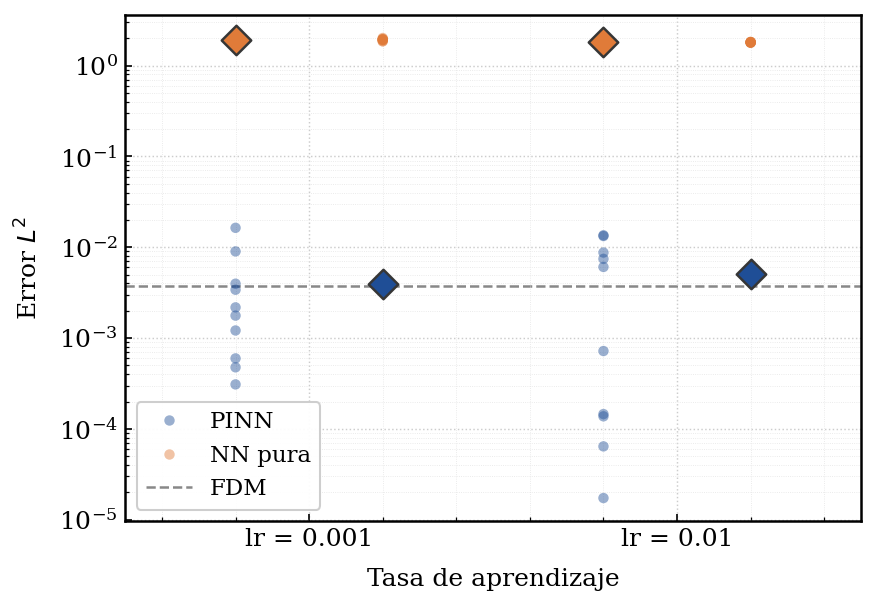

lr=0.001: PINN=3.9263e-03 ± 5.0726e-03 | NN=1.9231e+00 ± 4.8972e-02
lr=0.01: PINN=5.0146e-03 ± 5.5496e-03 | NN=1.8008e+00 ± 1.3609e-02
FDM: 3.7735e-03


In [11]:
mask_eje6_pozo = (
    df_pozo["lr"].isin([0.001, 0.01]) &
    (df_pozo["estado_n"]           == BASE_POZO["estado_n"]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["num_train_points"]   == BASE_POZO["num_train_points"]) &
    (df_pozo["train_region"]       == BASE_POZO["train_region"]) &
    (df_pozo["sampler"]            == BASE_POZO["sampler"]) &
    (df_pozo["use_dynamic_weights"]== BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]          == BASE_POZO["optimizer"]) &
    (df_pozo["hidden_layers"]      == BASE_POZO["hidden_layers"]) &
    (df_pozo["use_data"]           == BASE_POZO["use_data"])
)

df_eje6_pozo = df_pozo[mask_eje6_pozo].copy()
df_eje6_pozo["lr"] = df_eje6_pozo["lr"].astype(str)

df_eje6_pozo_long = df_eje6_pozo.melt(
    id_vars=["lr"],
    value_vars=["error_l2_pinn", "error_l2_nn"],
    var_name="modelo", value_name="error_l2"
).replace({"error_l2_pinn": "PINN", "error_l2_nn": "NN pura"})

df_eje6_pozo_long["lr_label"] = df_eje6_pozo_long["lr"].map(
    {"0.001": "lr = 0.001", "0.01": "lr = 0.01"}
)

fig, ax = plt.subplots(figsize=(6, 4.2))

sns.stripplot(
    data=df_eje6_pozo_long, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=5, alpha=0.45, jitter=False, ax=ax
)
means_eje6 = df_eje6_pozo_long.groupby(["lr_label", "modelo"])["error_l2"].mean().reset_index()
sns.stripplot(
    data=means_eje6, x="lr_label", y="error_l2", hue="modelo",
    palette={"PINN": C_PINN, "NN pura": C_NN},
    order=["lr = 0.001", "lr = 0.01"],
    dodge=True, size=10, marker="D", jitter=False,
    linewidth=1.2, ax=ax, legend=False
)
ax.axhline(
    df_base_pozo["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", zorder=0, label="FDM"
)

handles, labels = ax.get_legend_handles_labels()
seen = set()
h, l = [], []
for handle, label in zip(handles, labels):
    if label not in seen:
        seen.add(label)
        h.append(handle)
        l.append(label)
ax.legend(h, l, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=11, title=None)

ax.set_xlabel("Tasa de aprendizaje", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje6_lr.png", dpi=300, bbox_inches="tight")
plt.show()

for lr_val, grp in df_pozo[mask_eje6_pozo].groupby("lr"):
    print(f"lr={lr_val}: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"FDM: {df_base_pozo['error_l2_fdm'].mean():.4e}")

## Ejes 7 y 9 — Puntos de entrenamiento × región

Se estudia el efecto del número de puntos de entrenamiento supervisado (3, 5, 10,
15, 30) para dos regiones distintas: 20% y 50% del dominio. A diferencia del
oscilador clásico, aquí la NN también se beneficia de más datos, por lo que se
incluye en ambos paneles.

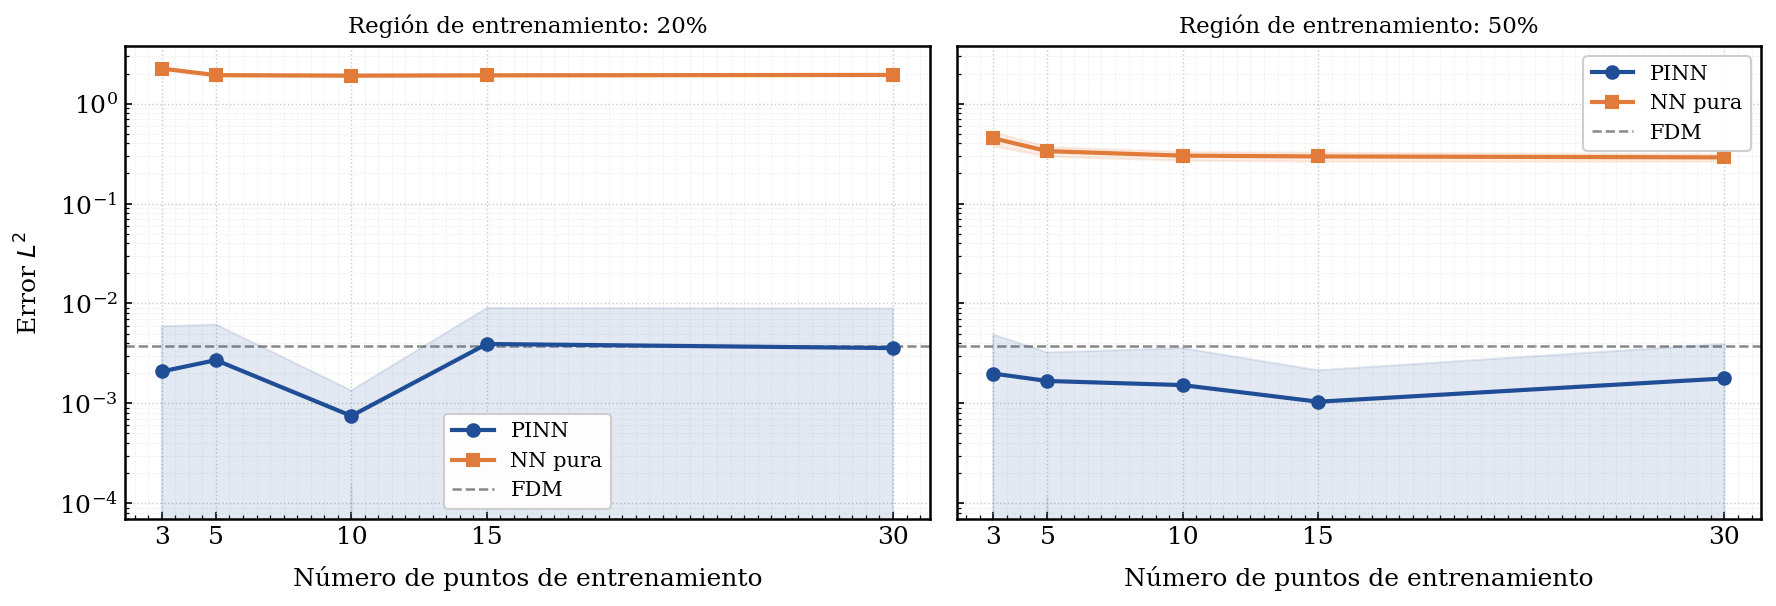

Región 20%:
  3 pts: PINN=2.0845e-03 ± 3.8194e-03 | NN=2.2481e+00 ± 5.4466e-02
  5 pts: PINN=2.7064e-03 ± 3.4487e-03 | NN=1.9317e+00 ± 6.6160e-02
  10 pts: PINN=7.4791e-04 ± 5.9543e-04 | NN=1.9096e+00 ± 5.0993e-02
  15 pts: PINN=3.9263e-03 ± 5.0726e-03 | NN=1.9231e+00 ± 4.8972e-02
  30 pts: PINN=3.5712e-03 ± 5.3305e-03 | NN=1.9412e+00 ± 4.8026e-02

Región 50%:
  3 pts: PINN=1.9871e-03 ± 2.8975e-03 | NN=4.5100e-01 ± 7.2713e-02
  5 pts: PINN=1.6740e-03 ± 1.5601e-03 | NN=3.3498e-01 ± 3.7382e-02
  10 pts: PINN=1.5216e-03 ± 2.0456e-03 | NN=3.0172e-01 ± 3.0565e-02
  15 pts: PINN=1.0372e-03 ± 1.1033e-03 | NN=2.9632e-01 ± 3.0877e-02
  30 pts: PINN=1.7737e-03 ± 2.1619e-03 | NN=2.8997e-01 ± 2.4219e-02

FDM: 3.7735e-03


In [12]:
mask_eje7_pozo = (
    (df_pozo["train_region"]       == 0.2) &
    (df_pozo["estado_n"]           == BASE_POZO["estado_n"]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["sampler"]            == BASE_POZO["sampler"]) &
    (df_pozo["use_dynamic_weights"]== BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]          == BASE_POZO["optimizer"]) &
    (df_pozo["hidden_layers"]      == BASE_POZO["hidden_layers"]) &
    (df_pozo["lr"]                 == BASE_POZO["lr"]) &
    (df_pozo["use_data"]           == BASE_POZO["use_data"])
)

mask_eje9_pozo = (
    (df_pozo["train_region"]       == 0.5) &
    (df_pozo["estado_n"]           == BASE_POZO["estado_n"]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["sampler"]            == BASE_POZO["sampler"]) &
    (df_pozo["use_dynamic_weights"]== BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]          == BASE_POZO["optimizer"]) &
    (df_pozo["hidden_layers"]      == BASE_POZO["hidden_layers"]) &
    (df_pozo["lr"]                 == BASE_POZO["lr"]) &
    (df_pozo["use_data"]           == BASE_POZO["use_data"])
)

df_eje7_pozo = df_pozo[mask_eje7_pozo].groupby("num_train_points")[
    ["error_l2_pinn", "error_l2_nn"]
].agg(["mean", "std"]).reset_index()

df_eje9_pozo = df_pozo[mask_eje9_pozo].groupby("num_train_points")[
    ["error_l2_pinn", "error_l2_nn"]
].agg(["mean", "std"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

for ax, df_e, region in zip(axes, [df_eje7_pozo, df_eje9_pozo], ["20%", "50%"]):
    x  = df_e["num_train_points"].values
    yp = df_e["error_l2_pinn"]["mean"].values
    sp = df_e["error_l2_pinn"]["std"].values
    yn = df_e["error_l2_nn"]["mean"].values
    sn = df_e["error_l2_nn"]["std"].values

    ax.plot(x, yp, "o-", color=C_PINN, linewidth=2, markersize=6,
            label="PINN", zorder=3)
    ax.fill_between(x, yp - sp, yp + sp, color=C_PINN, alpha=0.12, zorder=2)

    ax.plot(x, yn, "s-", color=C_NN, linewidth=2, markersize=6,
            label="NN pura", zorder=3)
    ax.fill_between(x, yn - sn, yn + sn, color=C_NN, alpha=0.12, zorder=2)

    ax.axhline(df_base_pozo["error_l2_fdm"].mean(), color=C_FDM,
               linewidth=1.2, linestyle="--", label="FDM", zorder=1)

    ax.set_title(f"Región de entrenamiento: {region}", fontsize=11)
    ax.set_xlabel("Número de puntos de entrenamiento", labelpad=8)
    ax.set_yscale("log")
    ax.set_xticks([3, 5, 10, 15, 30])
    ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
    ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc")
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5")

axes[0].set_ylabel("Error $L^2$", labelpad=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje7_9_train_points.png", dpi=300, bbox_inches="tight")
plt.show()

print("Región 20%:")
for pts, grp in df_pozo[mask_eje7_pozo].groupby("num_train_points"):
    print(f"  {pts} pts: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print("\nRegión 50%:")
for pts, grp in df_pozo[mask_eje9_pozo].groupby("num_train_points"):
    print(f"  {pts} pts: PINN={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| NN={grp['error_l2_nn'].mean():.4e} ± {grp['error_l2_nn'].std():.4e}")
print(f"\nFDM: {df_base_pozo['error_l2_fdm'].mean():.4e}")

## Eje 10 — Estado cuántico

Este eje es exclusivo del pozo infinito. Se estudia cómo varía el rendimiento
de los tres métodos al aumentar el número cuántico n (1, 2, 3, 4). A mayor n,
la función de onda presenta más oscilaciones, lo que supone un reto creciente
para la red neuronal. Además de el error L2, se analiza el error relativo en
el autovalor aprendido por la PINN frente al calculado por FDM.

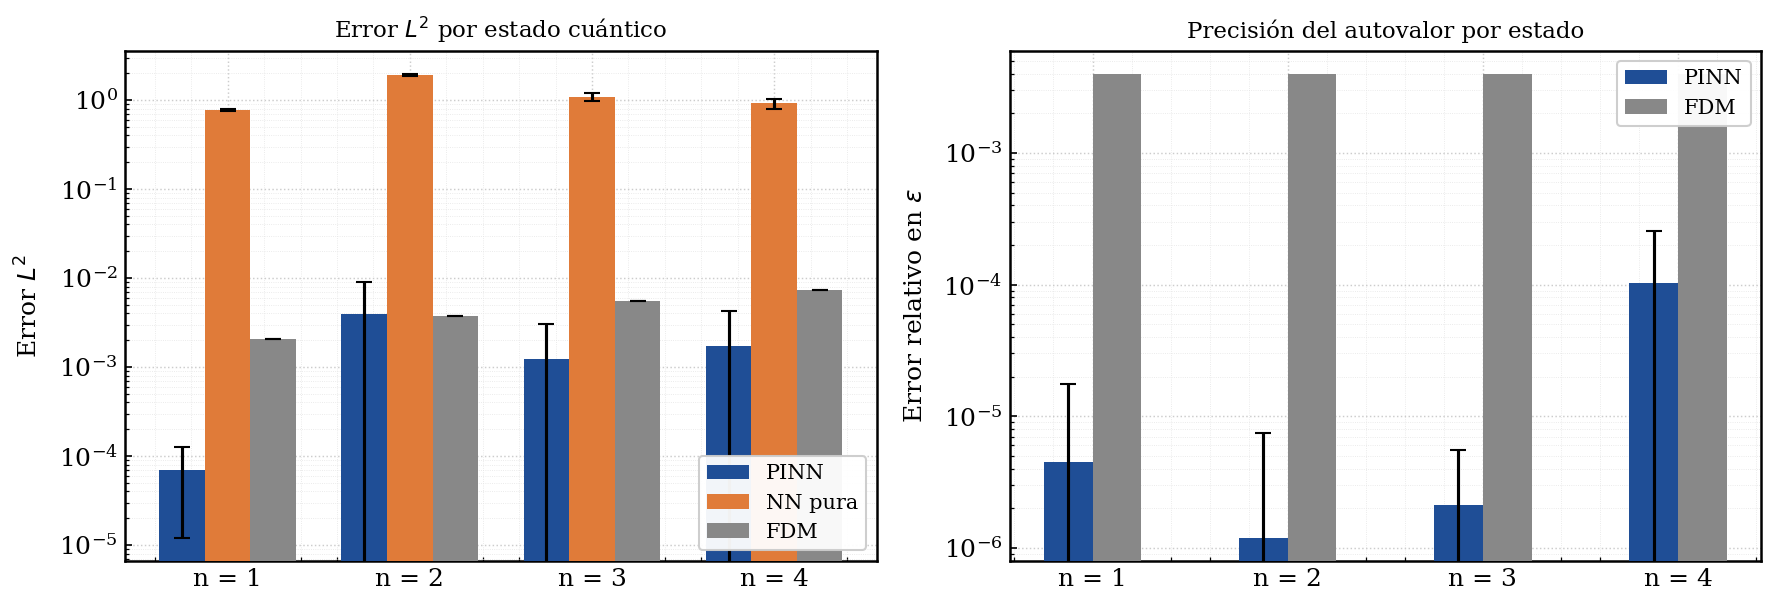

n           PINN L2        NN L2       FDM L2   ε exacto     ε PINN      ε FDM
1        6.8948e-05   7.7677e-01   2.0760e-03     4.9348     4.9348     4.9151
2        3.9263e-03   1.9231e+00   3.7735e-03    19.7392    19.7392    19.6603
3        1.2222e-03   1.0856e+00   5.5486e-03    44.4132    44.4133    44.2356
4        1.7282e-03   9.1472e-01   7.3454e-03    78.9568    78.9487    78.6406


In [13]:
mask_eje10_pozo = (
    df_pozo["estado_n"].isin([1, 2, 3, 4]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["num_train_points"]   == BASE_POZO["num_train_points"]) &
    (df_pozo["train_region"]       == BASE_POZO["train_region"]) &
    (df_pozo["sampler"]            == BASE_POZO["sampler"]) &
    (df_pozo["use_dynamic_weights"]== BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]          == BASE_POZO["optimizer"]) &
    (df_pozo["hidden_layers"]      == BASE_POZO["hidden_layers"]) &
    (df_pozo["lr"]                 == BASE_POZO["lr"]) &
    (df_pozo["use_data"]           == BASE_POZO["use_data"])
)

df_eje10 = df_pozo[mask_eje10_pozo].groupby("estado_n").agg(
    pinn_mean    =("error_l2_pinn",   "mean"),
    pinn_std     =("error_l2_pinn",   "std"),
    nn_mean      =("error_l2_nn",     "mean"),
    nn_std       =("error_l2_nn",     "std"),
    fdm_mean     =("error_l2_fdm",    "mean"),
    fdm_std      =("error_l2_fdm",    "std"),
    eps_exact    =("epsilon_exacto",  "first"),
    eps_pinn_mean=("epsilon_learned", "mean"),
    eps_pinn_std =("epsilon_learned", "std"),
    eps_fdm_mean =("epsilon_fdm",     "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ── Panel izquierdo: error L2 por estado ──────────────────────────────────
ax = axes[0]
x = df_eje10["estado_n"].values
w = 0.25

ax.bar(x - w, df_eje10["pinn_mean"], width=w, color=C_PINN,
       yerr=df_eje10["pinn_std"], capsize=4, label="PINN", zorder=3)
ax.bar(x,     df_eje10["nn_mean"],   width=w, color=C_NN,
       yerr=df_eje10["nn_std"],   capsize=4, label="NN pura", zorder=3)
ax.bar(x + w, df_eje10["fdm_mean"], width=w, color=C_FDM,
       yerr=df_eje10["fdm_std"],  capsize=4, label="FDM", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([f"n = {n}" for n in x])
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$ por estado cuántico", fontsize=11)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: error relativo en autovalor ────────────────────────────
ax = axes[1]
eps_err_pinn     = np.abs(df_eje10["eps_pinn_mean"] - df_eje10["eps_exact"]) / df_eje10["eps_exact"]
eps_err_pinn_std = df_eje10["eps_pinn_std"] / df_eje10["eps_exact"]
eps_err_fdm      = np.abs(df_eje10["eps_fdm_mean"]  - df_eje10["eps_exact"]) / df_eje10["eps_exact"]

ax.bar(x - w/2, eps_err_pinn, width=w, color=C_PINN,
       yerr=eps_err_pinn_std, capsize=4, label="PINN", zorder=3)
ax.bar(x + w/2, eps_err_fdm,  width=w, color=C_FDM,
       capsize=4, label="FDM", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([f"n = {n}" for n in x])
ax.set_ylabel("Error relativo en $\\varepsilon$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Precisión del autovalor por estado", fontsize=11)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje10_estado_cuantico.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'n':<6} {'PINN L2':>12} {'NN L2':>12} {'FDM L2':>12} "
      f"{'ε exacto':>10} {'ε PINN':>10} {'ε FDM':>10}")
for _, row in df_eje10.iterrows():
    print(f"{int(row['estado_n']):<6} {row['pinn_mean']:>12.4e} {row['nn_mean']:>12.4e} "
          f"{row['fdm_mean']:>12.4e} {row['eps_exact']:>10.4f} "
          f"{row['eps_pinn_mean']:>10.4f} {row['eps_fdm_mean']:>10.4f}")

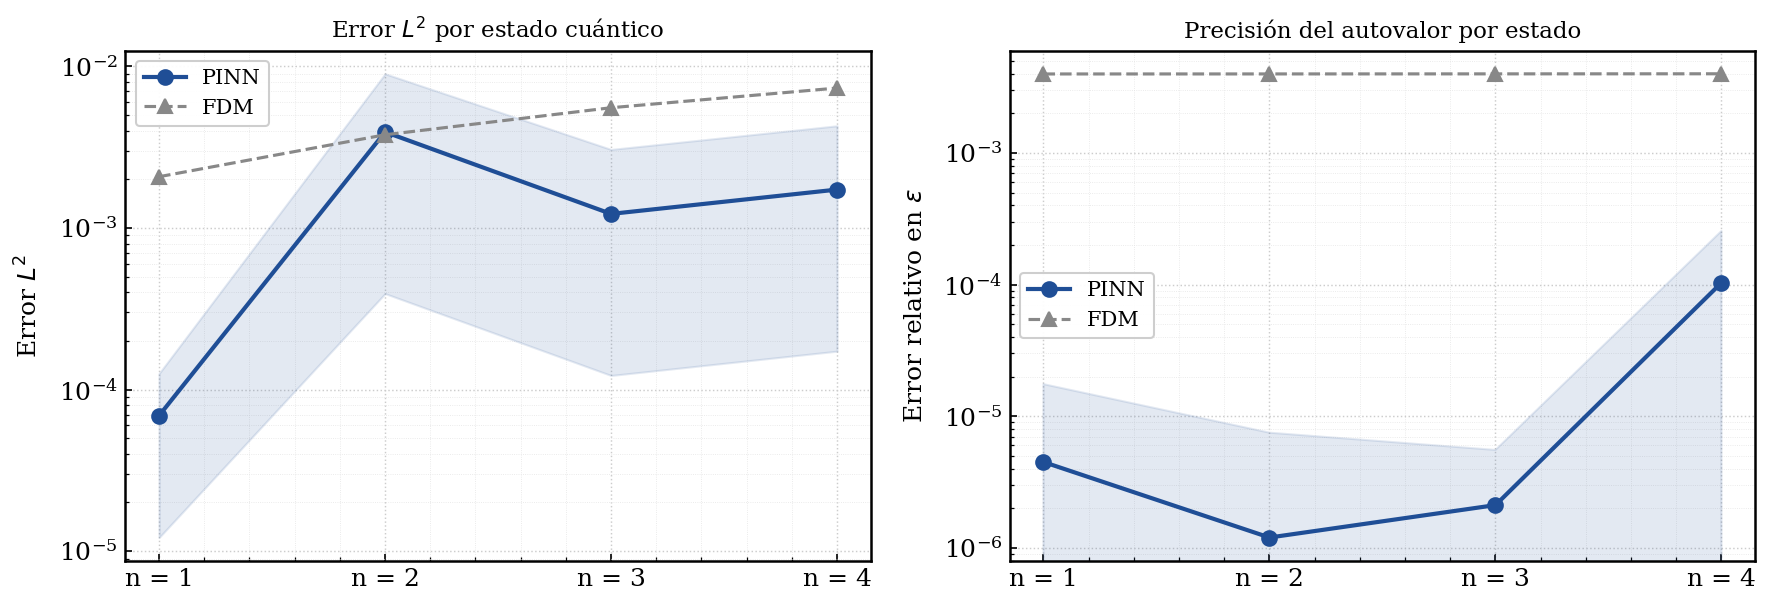

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = df_eje10["estado_n"].values

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
ax.plot(x, df_eje10["pinn_mean"], "o-", color=C_PINN, linewidth=2,
        markersize=7, label="PINN", zorder=3)
ax.fill_between(x,
    np.maximum(df_eje10["pinn_mean"] - df_eje10["pinn_std"],
               df_eje10["pinn_mean"] * 0.1),
    df_eje10["pinn_mean"] + df_eje10["pinn_std"],
    color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, df_eje10["fdm_mean"], "^--", color=C_FDM, linewidth=1.5,
        markersize=7, label="FDM", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([f"n = {n}" for n in x])
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Error $L^2$ por estado cuántico", fontsize=11)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: error relativo autovalor ───────────────────────────────
ax = axes[1]
eps_err_pinn     = np.abs(df_eje10["eps_pinn_mean"] - df_eje10["eps_exact"]) / df_eje10["eps_exact"]
eps_err_pinn_std = df_eje10["eps_pinn_std"] / df_eje10["eps_exact"]
eps_err_fdm      = np.abs(df_eje10["eps_fdm_mean"]  - df_eje10["eps_exact"]) / df_eje10["eps_exact"]

ax.plot(x, eps_err_pinn, "o-", color=C_PINN, linewidth=2,
        markersize=7, label="PINN", zorder=3)
ax.fill_between(x, eps_err_pinn - eps_err_pinn_std,
                   eps_err_pinn + eps_err_pinn_std,
                color=C_PINN, alpha=0.12, zorder=2)
ax.plot(x, eps_err_fdm, "^--", color=C_FDM, linewidth=1.5,
        markersize=7, label="FDM", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([f"n = {n}" for n in x])
ax.set_ylabel("Error relativo en $\\varepsilon$", labelpad=8)
ax.set_yscale("log")
ax.set_title("Precisión del autovalor por estado", fontsize=11)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje10_estado_cuantico.png", dpi=300, bbox_inches="tight")
plt.show()

## Eje 11 — Sin datos supervisados

Se estudia el caso en que la PINN opera únicamente con la pérdida física,
sin ningún punto de entrenamiento supervisado (use_data=False). Este modo
es exclusivo de la PINN — la NN pura no puede entrenarse sin datos, por lo
que se omite de la comparación. Se contrasta frente al BASE (con datos) y
frente a FDM.

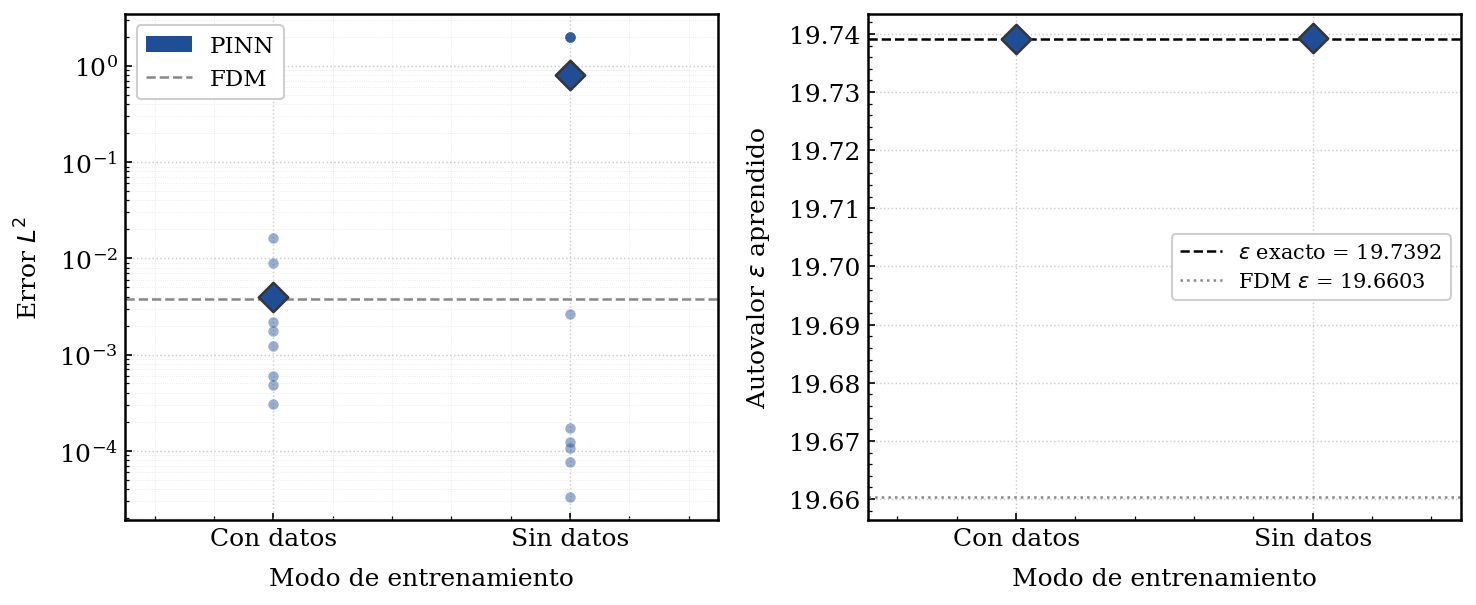

Con datos:  PINN=3.9263e-03 ± 5.0726e-03 | ε=19.739185 ± 0.000125
Sin datos:  PINN=8.0031e-01 ± 1.0325e+00 | ε=19.739222 ± 0.000126
ε exacto:   19.739209
FDM:        error=3.7735e-03 | ε=19.660345


In [20]:
mask_eje11_pozo = (
    (df_pozo["use_data"]           == False) &
    (df_pozo["estado_n"]           == BASE_POZO["estado_n"]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["num_train_points"]   == BASE_POZO["num_train_points"]) &
    (df_pozo["train_region"]       == BASE_POZO["train_region"]) &
    (df_pozo["sampler"]            == BASE_POZO["sampler"]) &
    (df_pozo["use_dynamic_weights"]== BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]          == BASE_POZO["optimizer"]) &
    (df_pozo["hidden_layers"]      == BASE_POZO["hidden_layers"]) &
    (df_pozo["lr"]                 == BASE_POZO["lr"])
)

grp11 = df_pozo[mask_eje11_pozo]

# Construir DataFrame para strip plot: BASE vs sin datos
df_eje11 = pd.concat([
    df_base_pozo[["error_l2_pinn", "epsilon_learned"]].assign(modo="Con datos"),
    grp11[["error_l2_pinn", "epsilon_learned"]].assign(modo="Sin datos"),
])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# ── Panel izquierdo: error L2 ─────────────────────────────────────────────
ax = axes[0]
sns.stripplot(
    data=df_eje11, x="modo", y="error_l2_pinn",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_11 = df_eje11.groupby("modo")["error_l2_pinn"].mean().reset_index()
sns.stripplot(
    data=means_11, x="modo", y="error_l2_pinn",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)

ax.axhline(
    df_base_pozo["error_l2_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle="--", label="FDM", zorder=2
)
from matplotlib.patches import Patch
pinn_patch = Patch(facecolor=C_PINN, label="PINN")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[pinn_patch] + handles, frameon=True,
          framealpha=0.95, edgecolor="#cccccc", fontsize=11)
ax.set_xlabel("Modo de entrenamiento", labelpad=8)
ax.set_ylabel("Error $L^2$", labelpad=8)
ax.set_yscale("log")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Panel derecho: autovalor aprendido ────────────────────────────────────
ax = axes[1]
eps_exacto = df_base_pozo["epsilon_exacto"].iloc[0]

sns.stripplot(
    data=df_eje11, x="modo", y="epsilon_learned",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=5, alpha=0.45, jitter=False, ax=ax
)
means_eps = df_eje11.groupby("modo")["epsilon_learned"].mean().reset_index()
sns.stripplot(
    data=means_eps, x="modo", y="epsilon_learned",
    color=C_PINN, order=["Con datos", "Sin datos"],
    size=10, marker="D", jitter=False, linewidth=1.2, ax=ax
)
ax.axhline(eps_exacto, color="black", linewidth=1.2,
           linestyle="--", label=f"$\\varepsilon$ exacto = {eps_exacto:.4f}")
ax.axhline(
    df_base_pozo["epsilon_fdm"].mean(),
    color=C_FDM, linewidth=1.2, linestyle=":",
    label=f"FDM $\\varepsilon$ = {df_base_pozo['epsilon_fdm'].mean():.4f}"
)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.set_xlabel("Modo de entrenamiento", labelpad=8)
ax.set_ylabel("Autovalor $\\varepsilon$ aprendido", labelpad=8)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje11_sin_datos.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Con datos:  PINN={df_base_pozo['error_l2_pinn'].mean():.4e} ± {df_base_pozo['error_l2_pinn'].std():.4e} "
      f"| ε={df_base_pozo['epsilon_learned'].mean():.6f} ± {df_base_pozo['epsilon_learned'].std():.6f}")
print(f"Sin datos:  PINN={grp11['error_l2_pinn'].mean():.4e} ± {grp11['error_l2_pinn'].std():.4e} "
      f"| ε={grp11['epsilon_learned'].mean():.6f} ± {grp11['epsilon_learned'].std():.6f}")
print(f"ε exacto:   {eps_exacto:.6f}")
print(f"FDM:        error={df_base_pozo['error_l2_fdm'].mean():.4e} "
      f"| ε={df_base_pozo['epsilon_fdm'].mean():.6f}")

## Tabla resumen — todos los ejes

In [16]:
BASE_POZO_MASK = {
    "estado_n":            2,
    "num_domain_points":   500,
    "num_train_points":    15,
    "train_region":        0.2,
    "sampler":             "lhs",
    "use_dynamic_weights": False,
    "use_orthogonality":   False,
    "optimizer":           "adam",
    "hidden_layers":       "[32, 32, 32]",
    "lr":                  0.001,
    "use_data":            True,
}

resumen_pozo = []

# ── BASE ──────────────────────────────────────────────────────────────────
resumen_pozo.append({
    "Eje":           "BASE",
    "Configuración": "—",
    "PINN media":    df_base_pozo["error_l2_pinn"].mean(),
    "PINN std":      df_base_pozo["error_l2_pinn"].std(),
    "NN media":      df_base_pozo["error_l2_nn"].mean(),
    "NN std":        df_base_pozo["error_l2_nn"].std(),
    "FDM media":     df_base_pozo["error_l2_fdm"].mean(),
    "N":             len(df_base_pozo),
})

# ── Ejes ──────────────────────────────────────────────────────────────────
ejes_pozo = [
    ("Eje 1 · Puntos colocación",  "num_domain_points",   mask_eje1_pozo),
    ("Eje 2 · Sampler",            "sampler",             mask_eje2_pozo),
    ("Eje 3 · Optimizador",        "optimizer",           mask_eje3_pozo),
    ("Eje 4 · Arquitectura",       "hidden_layers",       mask_eje4_pozo),
    ("Eje 5 · Pesos dinámicos",    "use_dynamic_weights", mask_eje5_pozo),
    ("Eje 6 · Learning rate",      "lr",                  mask_eje6_pozo),
    ("Eje 7 · Puntos train 20%",   "num_train_points",    mask_eje7_pozo),
    ("Eje 9 · Puntos train 50%",   "num_train_points",    mask_eje9_pozo),
    ("Eje 10 · Estado cuántico",   "estado_n",            mask_eje10_pozo),
]

for eje_label, col, mask in ejes_pozo:
    for val, grp in df_pozo[mask].groupby(col):
        resumen_pozo.append({
            "Eje":           eje_label,
            "Configuración": str(val),
            "PINN media":    grp["error_l2_pinn"].mean(),
            "PINN std":      grp["error_l2_pinn"].std(),
            "NN media":      grp["error_l2_nn"].mean(),
            "NN std":        grp["error_l2_nn"].std(),
            "FDM media":     grp["error_l2_fdm"].mean(),
            "N":             len(grp),
        })

# ── Eje 11: sin datos ─────────────────────────────────────────────────────
mask_eje11_pozo = (
    (df_pozo["use_data"]           == False) &
    (df_pozo["estado_n"]           == BASE_POZO["estado_n"]) &
    (df_pozo["num_domain_points"]  == BASE_POZO["num_domain_points"]) &
    (df_pozo["num_train_points"]   == BASE_POZO["num_train_points"]) &
    (df_pozo["train_region"]       == BASE_POZO["train_region"]) &
    (df_pozo["sampler"]            == BASE_POZO["sampler"]) &
    (df_pozo["use_dynamic_weights"]== BASE_POZO["use_dynamic_weights"]) &
    (df_pozo["use_orthogonality"]  == BASE_POZO["use_orthogonality"]) &
    (df_pozo["optimizer"]          == BASE_POZO["optimizer"]) &
    (df_pozo["hidden_layers"]      == BASE_POZO["hidden_layers"]) &
    (df_pozo["lr"]                 == BASE_POZO["lr"])
)

grp11 = df_pozo[mask_eje11_pozo]
resumen_pozo.append({
    "Eje":           "Eje 11 · Sin datos",
    "Configuración": "use_data=False",
    "PINN media":    grp11["error_l2_pinn"].mean(),
    "PINN std":      grp11["error_l2_pinn"].std(),
    "NN media":      float("nan"),
    "NN std":        float("nan"),
    "FDM media":     grp11["error_l2_fdm"].mean(),
    "N":             len(grp11),
})

# ── Formatear y mostrar ───────────────────────────────────────────────────
df_resumen_pozo = pd.DataFrame(resumen_pozo)

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 130)

print(f"\n{'═'*115}")
print(f"{'EJE':<30} {'CONFIG':<18} {'PINN media':>12} {'PINN std':>12} "
      f"{'NN media':>12} {'NN std':>12} {'FDM media':>12} {'N':>4}")
print(f"{'─'*115}")

eje_actual = None
for _, row in df_resumen_pozo.iterrows():
    if row["Eje"] != eje_actual:
        if eje_actual is not None:
            print(f"{'─'*115}")
        eje_actual = row["Eje"]
    nn_media = f"{row['NN media']:.3e}" if not pd.isna(row["NN media"]) else "N/A"
    nn_std   = f"{row['NN std']:.3e}"   if not pd.isna(row["NN std"])   else "N/A"
    print(f"{row['Eje']:<30} {row['Configuración']:<18} "
          f"{row['PINN media']:>12.3e} {row['PINN std']:>12.3e} "
          f"{nn_media:>12} {nn_std:>12} "
          f"{row['FDM media']:>12.3e} {int(row['N']):>4}")

print(f"{'═'*115}")


═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
EJE                            CONFIG               PINN media     PINN std     NN media       NN std    FDM media    N
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BASE                           —                     3.926e-03    5.073e-03    1.923e+00    4.897e-02    3.773e-03   10
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Eje 1 · Puntos colocación      50                    3.934e-03    3.430e-03    1.923e+00    4.897e-02    3.773e-03   10
Eje 1 · Puntos colocación      100                   2.386e-03    3.411e-03    1.923e+00    4.897e-02    3.773e-03   10
Eje 1 · Puntos colocación      250                   1.122e-03    1.582e-03    1.923e+00    4.897e-02    3.773e-03   10
Eje 1 · Puntos colocación      500                 